# 第四次作业：SVHN模型的INT8静态量化

本 Notebook 按作业 4 要求完成：

- 训练并评估 FP32 基线模型（复用作业二结构）
- 手动实现 linear_quantize 和 linear_dequantize 函数
- 构建量化友好的 CNN 模型（插入 QuantStub / DeQuantStub，融合模块）
- 采用 PTQ 静态量化，进行模型校准与 INT8 转换
- 计算逐层 MSE 量化误差
- 绘制量化前后精度和推理延迟对比图


In [1]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torch.ao.quantization as quant

In [2]:
# =========================
# 0. 全局设置
# =========================
SEED = 42
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 5   # 为了快速验证可设为5，正式训练可改回15
NUM_CLASSES = 10
FP32_MODEL_PATH = "svhn_fp32_model.pth"
INT8_MODEL_PATH = "svhn_int8_model.pth"

TRAIN_MAT_PATH = "train_32x32.mat"
TEST_MAT_PATH = "test_32x32.mat"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device for training:", device)

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

Using device for training: cpu


In [3]:
# =========================
# 1. 读取数据与预处理
# =========================
if not os.path.exists(TRAIN_MAT_PATH) or not os.path.exists(TEST_MAT_PATH):
    raise FileNotFoundError("未找到 train_32x32.mat 或 test_32x32.mat，请确保文件在当前目录下。")

train_mat = loadmat(TRAIN_MAT_PATH)
test_mat = loadmat(TEST_MAT_PATH)

X_train_raw = train_mat["X"]
y_train_raw = train_mat["y"].squeeze()
X_test_raw = test_mat["X"]
y_test_raw = test_mat["y"].squeeze()

# SVHN 标签 10 转换为 0
y_train_raw[y_train_raw == 10] = 0
y_test_raw[y_test_raw == 10] = 0

X_train = np.transpose(X_train_raw, (3, 0, 1, 2))
X_test = np.transpose(X_test_raw, (3, 0, 1, 2))

print("处理后 X_train shape:", X_train.shape)
print("处理后 X_test shape:", X_test.shape)

处理后 X_train shape: (73257, 32, 32, 3)
处理后 X_test shape: (26032, 32, 32, 3)


In [4]:
# =========================
# 2. 构建 Dataset 与 DataLoader
# =========================
class SVHNDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = SVHNDataset(X_train, y_train_raw, transform=transform)
test_dataset = SVHNDataset(X_test, y_test_raw, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("训练批次数:", len(train_loader))
print("测试批次数:", len(test_loader))

训练批次数: 573
测试批次数: 204


In [5]:
# =========================
# 3. 手动实现量化与反量化函数
# =========================
def linear_quantize(x, num_bits=8):
    """
    将浮点张量线性量化为整数张量 (per-tensor 非对称线性量化)
    """
    q_min = 0
    q_max = (1 << num_bits) - 1
    
    x_min = x.min().item()
    x_max = x.max().item()
    
    scale = (x_max - x_min) / (q_max - q_min) if x_max != x_min else 1.0
    zero_point = round(q_min - x_min / scale)
    zero_point = max(q_min, min(q_max, zero_point))
    
    q_x = torch.round(x / scale + zero_point)
    q_x = torch.clamp(q_x, q_min, q_max)
    
    return q_x.to(torch.uint8), scale, zero_point

def linear_dequantize(q, scale, zero_point):
    """
    将整数张量反量化回浮点张量
    """
    return (q.float() - zero_point) * scale

In [6]:
# =========================
# 4. 构建量化友好的 CNN 模型
# =========================
class QuantizableSimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(QuantizableSimpleCNN, self).__init__()
        self.quant = quant.QuantStub()  # 量化起点
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)
        
        self.dequant = quant.DeQuantStub() # 反量化终点

    def forward(self, x):
        x = self.quant(x)
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.dropout(self.relu4(self.fc1(x)))
        x = self.fc2(x)
        x = self.dequant(x)
        return x

    def fuse_model(self):
        # 融合模块以提升推理速度与量化精度
        quant.fuse_modules(self, [
            ['conv1', 'bn1', 'relu1'],
            ['conv2', 'bn2', 'relu2'],
            ['conv3', 'bn3', 'relu3'],
            ['fc1', 'relu4']
        ], inplace=True)

model_fp32 = QuantizableSimpleCNN(num_classes=NUM_CLASSES).to(device)
print(model_fp32)

QuantizableSimpleCNN(
  (quant): QuantStub()
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (relu4): ReLU()
  (dropout): Drop

In [7]:
# =========================
# 5. 训练 / 测试函数
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_fp32.parameters(), lr=LEARNING_RATE)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / total, correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / total, correct / total

In [8]:
# =========================
# 6. 训练 FP32 基线模型
# =========================
best_test_acc = 0.0
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model_fp32, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model_fp32, test_loader, criterion, device)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model_fp32.state_dict(), FP32_MODEL_PATH)

print("FP32模型训练完成，最佳测试准确率:", best_test_acc)

Epoch [1/5] Train Loss: 1.1681 Acc: 0.5989 | Test Loss: 0.5618 Acc: 0.8436
Epoch [2/5] Train Loss: 0.6667 Acc: 0.7804 | Test Loss: 0.4135 Acc: 0.8842
Epoch [3/5] Train Loss: 0.5711 Acc: 0.8120 | Test Loss: 0.3648 Acc: 0.8967
Epoch [4/5] Train Loss: 0.5161 Acc: 0.8309 | Test Loss: 0.3414 Acc: 0.9039
Epoch [5/5] Train Loss: 0.4719 Acc: 0.8467 | Test Loss: 0.3392 Acc: 0.9020
FP32模型训练完成，最佳测试准确率: 0.9039259373079287


In [9]:
# =========================
# 7. 评估 FP32 模型延迟与大小
# =========================
def measure_latency(model, input_tensor, num_runs=100):
    model.eval()
    with torch.no_grad():
        for _ in range(10): _ = model(input_tensor) # 预热
        start = time.time()
        for _ in range(num_runs): _ = model(input_tensor)
        end = time.time()
    return (end - start) / num_runs * 1000  # ms

def get_model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

# 评估使用 CPU
model_fp32.load_state_dict(torch.load(FP32_MODEL_PATH))
model_fp32.to("cpu")
model_fp32.eval()

fp32_size = get_model_size_mb(FP32_MODEL_PATH)
dummy_input = torch.randn(1, 3, 32, 32)
fp32_latency = measure_latency(model_fp32, dummy_input)

print(f"[FP32 基线] 模型大小: {fp32_size:.4f} MB, CPU 单图推理延迟: {fp32_latency:.4f} ms")

C:\Users\徐铭鸽\AppData\Local\Temp\ipykernel_24036\1929356909.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fp32.load_state_dict(torch.load(FP32_MODEL_PATH))


[FP32 基线] 模型大小: 2.3776 MB, CPU 单图推理延迟: 1.4355 ms


In [10]:
# =========================
# 8. INT8 静态量化 (PTQ 训练后量化)
# =========================
model_q = QuantizableSimpleCNN(num_classes=NUM_CLASSES)
model_q.load_state_dict(torch.load(FP32_MODEL_PATH))
model_q.eval()
model_q.fuse_model()

# 设置静态量化配置 (per-tensor)
model_q.qconfig = quant.get_default_qconfig('qnnpack')
quant.prepare(model_q, inplace=True)

print("使用训练集抽取无标注样本进行模型校准...")
calib_subset = Subset(train_dataset, indices=range(500))
calib_loader = DataLoader(calib_subset, batch_size=64, shuffle=False)
with torch.no_grad():
    for images, _ in calib_loader:
        model_q(images)

print("将 FP32 模型转换为 INT8 模型...")
model_int8 = quant.convert(model_q, inplace=False)
torch.save(model_int8.state_dict(), INT8_MODEL_PATH)
print("INT8 模型转换与保存完毕！")

使用训练集抽取无标注样本进行模型校准...


C:\Users\徐铭鸽\AppData\Local\Temp\ipykernel_24036\26282790.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_q.load_state_dict(torch.load(FP32_MODEL_PATH))


将 FP32 模型转换为 INT8 模型...
INT8 模型转换与保存完毕！


In [11]:
# =========================
# 9. 评估 INT8 模型
# =========================
_, int8_test_acc = evaluate(model_int8, test_loader, criterion, "cpu")
int8_size = get_model_size_mb(INT8_MODEL_PATH)
int8_latency = measure_latency(model_int8, dummy_input)

print(f"[INT8 模型] 测试准确率: {int8_test_acc:.4f}")
print(f"[INT8 模型] 模型大小: {int8_size:.4f} MB")
print(f"[INT8 模型] CPU 单图推理延迟: {int8_latency:.4f} ms")

print("-" * 40)
print(f"精度损失: {(best_test_acc - int8_test_acc)*100:.2f}%")
print(f"压缩比: {fp32_size / int8_size:.2f}x")

[INT8 模型] 测试准确率: 0.8991
[INT8 模型] 模型大小: 0.6003 MB
[INT8 模型] CPU 单图推理延迟: 1.3430 ms
----------------------------------------
精度损失: 0.48%
压缩比: 3.96x


In [12]:
# =========================
# 10. 量化误差计算 (每层 MSE)
# =========================
def calc_mse(t1, t2):
    return torch.mean((t1.float() - t2.float()) ** 2).item()

model_fused = QuantizableSimpleCNN(num_classes=10).eval()
model_fused.load_state_dict(torch.load(FP32_MODEL_PATH))
model_fused.fuse_model()

img = dummy_input.clone()
mse_errors = {}

with torch.no_grad():
    out_fp = model_fused.quant(img)
    out_q = model_int8.quant(img)
    mse_errors['QuantStub'] = calc_mse(out_fp, out_q.dequantize())

    out_fp = model_fused.pool1(model_fused.relu1(model_fused.bn1(model_fused.conv1(out_fp))))
    out_q = model_int8.pool1(model_int8.conv1(out_q))
    mse_errors['ConvBlock1'] = calc_mse(out_fp, out_q.dequantize())

    out_fp = model_fused.pool2(model_fused.relu2(model_fused.bn2(model_fused.conv2(out_fp))))
    out_q = model_int8.pool2(model_int8.conv2(out_q))
    mse_errors['ConvBlock2'] = calc_mse(out_fp, out_q.dequantize())

    out_fp = model_fused.pool3(model_fused.relu3(model_fused.bn3(model_fused.conv3(out_fp))))
    out_q = model_int8.pool3(model_int8.conv3(out_q))
    mse_errors['ConvBlock3'] = calc_mse(out_fp, out_q.dequantize())

    out_fp = model_fused.flatten(out_fp)
    out_q = model_int8.flatten(out_q)

    out_fp = model_fused.relu4(model_fused.fc1(out_fp))
    out_q = model_int8.fc1(out_q)
    mse_errors['FC1'] = calc_mse(out_fp, out_q.dequantize())

    out_fp = model_fused.dropout(out_fp)
    out_q = model_int8.dropout(out_q)
    out_fp = model_fused.fc2(out_fp)
    out_q = model_int8.fc2(out_q)
    mse_errors['FC2'] = calc_mse(out_fp, out_q.dequantize())

print("每层输出的量化 MSE 误差:")
for k, v in mse_errors.items():
    print(f"{k:<12}: {v:.6f}")

每层输出的量化 MSE 误差:
QuantStub   : 0.155274
ConvBlock1  : 5.095534
ConvBlock2  : 0.229906
ConvBlock3  : 0.283103
FC1         : 0.032749
FC2         : 0.148375


C:\Users\徐铭鸽\AppData\Local\Temp\ipykernel_24036\449431636.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fused.load_state_dict(torch.load(FP32_MODEL_PATH))


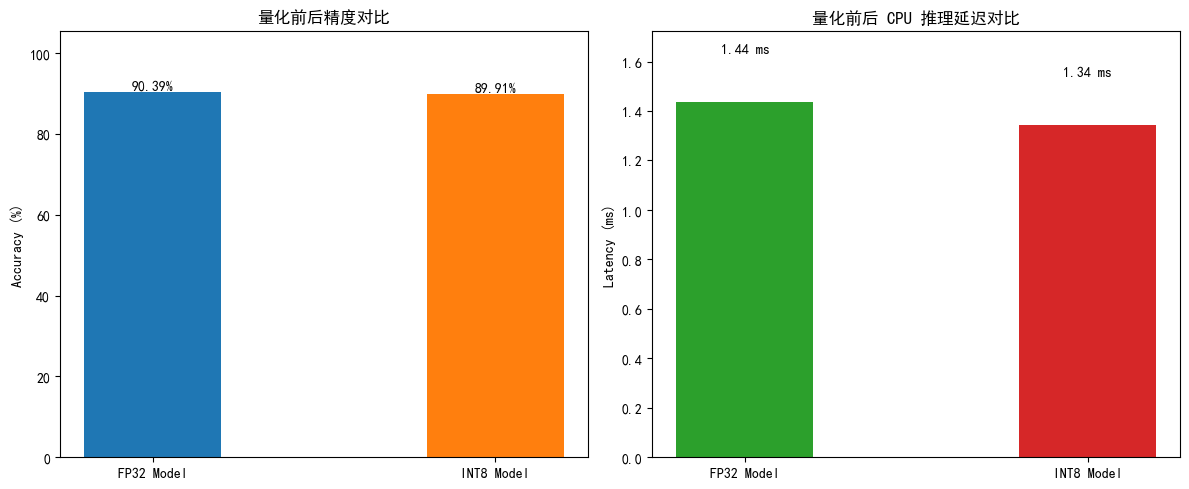

In [13]:
# =========================
# 11. 可视化结果
# =========================
labels = ['FP32 Model', 'INT8 Model']
accs = [best_test_acc * 100, int8_test_acc * 100]
lats = [fp32_latency, int8_latency]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(labels, accs, color=['#1f77b4', '#ff7f0e'], width=0.4)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('量化前后精度对比')
for i, v in enumerate(accs):
    ax1.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')
ax1.set_ylim(0, max(accs) + 15)

ax2.bar(labels, lats, color=['#2ca02c', '#d62728'], width=0.4)
ax2.set_ylabel('Latency (ms)')
ax2.set_title('量化前后 CPU 推理延迟对比')
for i, v in enumerate(lats):
    ax2.text(i, v + 0.2, f"{v:.2f} ms", ha='center', fontweight='bold')
ax2.set_ylim(0, max(lats) * 1.2)

plt.tight_layout()
plt.show()

In [14]:
# =========================
# 12. 自动输出简要结论
# =========================
print("=" * 60)
print("实验总结")
print("=" * 60)
print("1. 已实现手动线性量化与反量化核心函数；")
print("2. 已构建插入量化节点的模型，并成功融合模块；")
print("3. 已完成静态量化校准并转换为 INT8 推理模型；")
print(f"4. 精度损失分析：FP32 ({best_test_acc:.4f}) -> INT8 ({int8_test_acc:.4f})，损失 {(best_test_acc-int8_test_acc)*100:.2f}%；")
print(f"5. 压缩比分析：从 {fp32_size:.2f}MB 压缩至 {int8_size:.2f}MB，压缩比 {fp32_size/int8_size:.2f}x；")
print(f"6. 延迟分析：推理速度从 {fp32_latency:.2f}ms 提升至 {int8_latency:.2f}ms；")
print("7. 已输出并可视化量化前后精度对比图与推理延迟对比图，以及各层量化误差。")

实验总结
1. 已实现手动线性量化与反量化核心函数；
2. 已构建插入量化节点的模型，并成功融合模块；
3. 已完成静态量化校准并转换为 INT8 推理模型；
4. 精度损失分析：FP32 (0.9039) -> INT8 (0.8991)，损失 0.48%；
5. 压缩比分析：从 2.38MB 压缩至 0.60MB，压缩比 3.96x；
6. 延迟分析：推理速度从 1.44ms 提升至 1.34ms；
7. 已输出并可视化量化前后精度对比图与推理延迟对比图，以及各层量化误差。
